<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("akshatsharma2/all-in-one-dataset-for-preprocessing-practice")
print("Path to dataset files:", path)

100%|██████████| 7.07k/7.07k [00:00<00:00, 13.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/akshatsharma2/all-in-one-dataset-for-preprocessing-practice/versions/1


In [3]:
rng = np.random.default_rng()

# 01/

## Type of Features

In [4]:
df = pd.read_csv(f'{path}/my_data (1).csv')

df.head()

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1


In [5]:
df.shape

(1100, 7)

In [6]:
df.describe()

,age,cgpa,placed
count,982.000000,962.000000,1100.000000
mean,28.429735,7.609033,0.499091
std,9.141244,1.495991,0.500227
min,18.000000,4.010000,0.000000
25%,22.000000,7.170000,0.000000
50%,26.000000,7.925000,0.000000
75%,30.000000,8.760000,1.000000
max,50.000000,9.490000,1.000000


In [7]:
df.dtypes

,0
name,object
city,object
gender,object
profession,object
age,float64
cgpa,float64
placed,int64


In [8]:
features = {
    'nominal'  : ['name', 'city', 'gender'],
    'ordinal'  : ['profession'],
    'numerical': ['age', 'cgpa'],
    'label'    : ['placed']
}

In [9]:
missing = pd.DataFrame(index=df.columns)

missing['Null'] = df.isnull().sum()
missing['%'] = np.round(df.isnull().mean() * 100, 2)

missing

,Null,%
name,91,8.27
city,195,17.73
gender,106,9.64
profession,179,16.27
age,118,10.73
cgpa,138,12.55
placed,0,0.00


### Features Preprocessing and Transformation

In [10]:
df_transform = df.copy()

scaler = StandardScaler()
df_transform[features['numerical']] = scaler.fit_transform(df_transform[features['numerical']])

oe_nom = OrdinalEncoder()
df_transform[features['nominal']] = oe_nom.fit_transform(df_transform[features['nominal']])

prof = ['bachelor', 'masters', 'phd']
oe_ord = OrdinalEncoder(
    categories=[prof],
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)
df_transform[features['ordinal']] = oe_ord.fit_transform(df_transform[features['ordinal']])

In [11]:
df_transform.head()

,name,city,gender,profession,age,cgpa,placed
0,4.0,NaN,0.0,2.0,-0.047035,-1.116251,1
1,4.0,0.0,NaN,0.0,2.360866,0.629320,0
2,3.0,NaN,0.0,1.0,-1.141535,-1.370396,0
3,5.0,NaN,1.0,0.0,-0.375385,0.642696,1
4,5.0,NaN,1.0,0.0,-1.032085,0.769768,1


### Correlation

**Pearson Correlation Coefficient. Two Equivalent Forms**

Form 1: Computational Formula (using sums)
$$ r = \frac{\sum_{i=1}^{n} p_i q_i - n\bar{p}\bar{q}}{(n-1) s_p s_q} $$
> *Efficient for computation, especially with large datasets. Uses raw sums.*

Form 2: Definitional Formula (using deviations)
$$ r = \frac{\sum_{i=1}^{n} (p_i - \bar{p})(q_i - \bar{q})}{\sqrt{\sum_{i=1}^{n} (p_i - \bar{p})^2 \cdot \sum_{i=1}^{n} (q_i - \bar{q})^2}} $$
> *Intuitive interpretation: covariance normalized by the product of standard deviations.*

> **Note**: Both formulas are mathematically equivalent. Minor numerical differences (≤ 0.01) may arise due to floating-point precision and different order of operations.

In [12]:
# Sample ['city', 'age']

n = df.shape[0]
p = df_transform['city']
q = df_transform['age']

r1 = ( (p*q).sum() - n*p.mean()*q.mean() ) / ( (n - 1)*p.std()*q.std() )
r2 = ( (p - p.mean())*(q - q.mean()) ).sum() / ( np.sqrt( ((p - p.mean())**2).sum()*((q - q.mean())**2).sum() ) )

np.round(r1, 2), np.round(r2, 2), np.round(df_transform[['city', 'age']].corr().to_numpy()[0, 1], 2)

(np.float64(0.07), np.float64(0.06), np.float64(0.07))

Text(0.5, 1.0, 'Features Correlation')

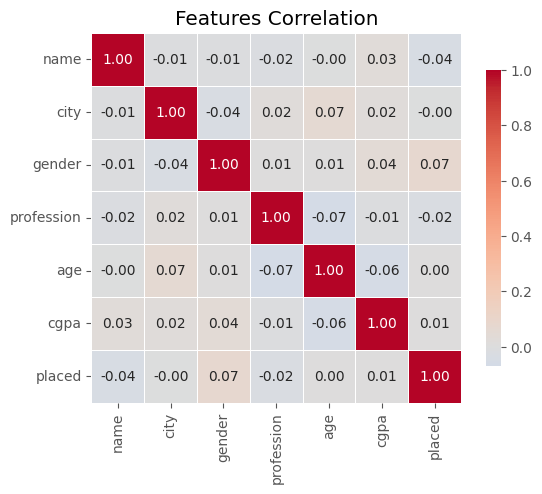

In [13]:
sns.heatmap(df_transform.corr(),
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})\
    .set_title('Features Correlation')

# 02/

## Missing Data Recovery

- delete object
- delete columns
- replace value

\

Recovery Formula:
$$
P(A) = \frac{1}{\sum_{i=1}^{n}\frac{1}{\rho(A, A_i)}}\sum_{i=1}^{n}\frac{A_i}{\rho(A, A_i)}
$$

, where $\rho$ is the metric

In [14]:
em_distance = lambda p, q: ((p - q)**2).sum(axis=1) # Euclidean metric
mm_distance = lambda p, q: np.abs(p - q).sum(axis=1) # Manhattan Geometry

metrics = {
    'euclidean': em_distance,
    'manhattan': mm_distance,
}


In [15]:
def recovery(row, col_for_recovery, metric='euclidean'):
    distances = metrics[metric](
        FULL_BASE.drop([col_for_recovery] + row['nan'], axis=1),
        row.drop('nan')
    )
    distances += 1e-10 # division-by-zero protection

    scale_factor = df.shape[1] / (df.shape[1] - len(row['nan']))
    actual_distance = 1 / (1 / distances).sum() * (FULL_BASE[col_for_recovery] / distances).sum()

    return actual_distance * np.sqrt(scale_factor)


### Recovery Numerical Features using Euclidean Metrics

Euclidean Metrics:
$$
\rho(P, Q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$


In [16]:
em = df_transform.copy()

em_scaler = StandardScaler()
em = pd.DataFrame(
    columns=em.columns,
    data=em_scaler.fit_transform(em)
)

em.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,NaN,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,NaN,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,NaN,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,NaN,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,NaN,0.554883,-0.799477,-1.032085,0.769768,1.001820


In [17]:
FULL_BASE = em.dropna() # all features are present

def get_recovery_df(column):
    recovery = em[em[column].isnull()].copy()
    recovery.drop(column, axis=1, inplace=True)
    recovery['nan'] = recovery.apply(lambda r: r[r.isna()].index.to_list(), axis=1)

    return recovery


#### Recovering Age

In [18]:
AGE_recovery = get_recovery_df('age')
AGE_recovery.head()

,name,city,gender,profession,cgpa,placed,nan
9,-1.633929,NaN,-1.802183,0.576819,0.495559,1.001820,[city]
19,1.829589,1.011774,0.554883,-0.799477,0.475495,-0.998183,[]
34,0.675083,-1.577261,NaN,NaN,-0.159866,-0.998183,"[gender, profession]"
38,0.675083,-0.714249,0.554883,-0.799477,0.174535,-0.998183,[]
70,0.097830,-0.714249,0.554883,-0.799477,-2.079325,-0.998183,[]


In [19]:
AGE_recovery['age'] = AGE_recovery.apply(recovery, col_for_recovery='age', axis=1)
AGE_recovery.head()

,name,city,gender,profession,cgpa,placed,nan,age
9,-1.633929,NaN,-1.802183,0.576819,0.495559,1.001820,[city],-0.039515
19,1.829589,1.011774,0.554883,-0.799477,0.475495,-0.998183,[],0.160776
34,0.675083,-1.577261,NaN,NaN,-0.159866,-0.998183,"[gender, profession]",-0.487309
38,0.675083,-0.714249,0.554883,-0.799477,0.174535,-0.998183,[],0.565862
70,0.097830,-0.714249,0.554883,-0.799477,-2.079325,-0.998183,[],0.012386


In [20]:
em_custom = em.copy()

em_custom.loc[em_custom['age'].isna(), 'age'] = AGE_recovery['age']

#### Recovering cgpa

In [21]:
CGPA_recovery = get_recovery_df('cgpa')
CGPA_recovery.head()

,name,city,gender,profession,age,placed,nan
11,0.097830,0.148762,0.554883,-0.799477,-0.047035,1.001820,[]
14,0.675083,1.011774,0.554883,-0.799477,-0.156485,-0.998183,[]
32,-1.056676,NaN,0.554883,0.576819,1.923066,-0.998183,[city]
37,0.675083,1.011774,-1.802183,NaN,-0.813185,1.001820,[profession]
39,0.675083,-0.714249,0.554883,1.953115,-0.375385,-0.998183,[]


In [22]:
CGPA_recovery['cgpa'] = CGPA_recovery.apply(recovery, col_for_recovery='cgpa', axis=1)
CGPA_recovery.head()

,name,city,gender,profession,age,placed,nan,cgpa
11,0.097830,0.148762,0.554883,-0.799477,-0.047035,1.001820,[],-0.229505
14,0.675083,1.011774,0.554883,-0.799477,-0.156485,-0.998183,[],-0.233434
32,-1.056676,NaN,0.554883,0.576819,1.923066,-0.998183,[city],-0.846280
37,0.675083,1.011774,-1.802183,NaN,-0.813185,1.001820,[profession],-0.487567
39,0.675083,-0.714249,0.554883,1.953115,-0.375385,-0.998183,[],-0.879102


In [23]:
em_custom.loc[em_custom['cgpa'].isna(), 'cgpa'] = CGPA_recovery['cgpa']

#### Recovering 'Age' and 'CGPA' w/ KNNImputer

In [24]:
imputer = KNNImputer(n_neighbors=5)

recovered = pd.DataFrame(
    data=imputer.fit_transform(em),
    columns=em.columns,
)

recovered.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,0.148762,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,0.083470,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,0.321365,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,-0.196442,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,-0.196442,0.554883,-0.799477,-1.032085,0.769768,1.001820


In [25]:
em_knnimputer = em.copy()

em_knnimputer.loc[em_knnimputer['age'].isna(), 'age'] = recovered.loc[em[em['age'].isna()]['age'].index, 'age']
em_knnimputer.loc[em_knnimputer['cgpa'].isna(), 'cgpa'] = recovered.loc[em[em['cgpa'].isna()]['cgpa'].index, 'cgpa']

em_knnimputer.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,NaN,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,NaN,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,NaN,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,NaN,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,NaN,0.554883,-0.799477,-1.032085,0.769768,1.001820


#### Comparison

In [26]:
NaN_age_idxs = em[em['age'].isna()].index
NaN_cgpa_idxs = em[em['cgpa'].isna()].index

In [27]:
original_custom = pd.DataFrame(
    data=em_scaler.inverse_transform(em_custom),
    columns=em_custom.columns
)

original_custom = pd.DataFrame(
    data=scaler.inverse_transform(original_custom[['age', 'cgpa']]),
    columns=['age', 'cgpa']
)

original_custom.head()

,age,cgpa
0,28.0,5.94
1,50.0,8.55
2,18.0,5.56
3,25.0,8.57
4,19.0,8.76


In [28]:
original_knnimputer = pd.DataFrame(
    data=em_scaler.inverse_transform(em_knnimputer),
    columns=em_knnimputer.columns
)

original_knnimputer = pd.DataFrame(
    data=scaler.inverse_transform(em_knnimputer[['age', 'cgpa']]),
    columns=['age', 'cgpa']
)

original_knnimputer.head()

,age,cgpa
0,28.0,5.94
1,50.0,8.55
2,18.0,5.56
3,25.0,8.57
4,19.0,8.76


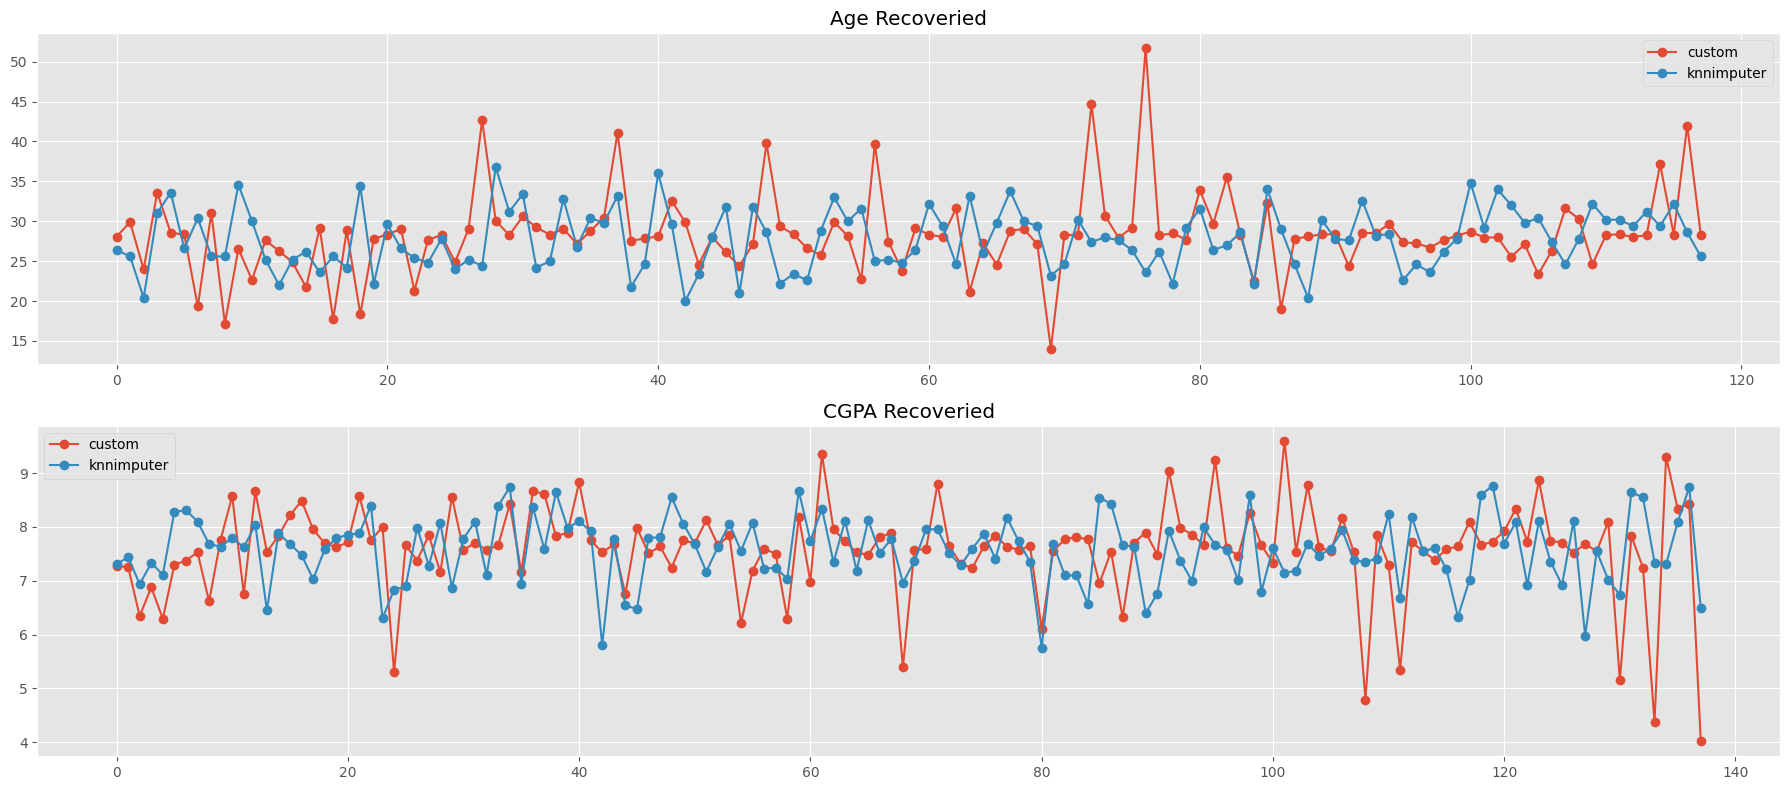

In [29]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(np.arange(len(NaN_age_idxs)), original_custom.loc[NaN_age_idxs]['age'], marker='o', label='custom')
axs[0].plot(np.arange(len(NaN_age_idxs)), original_knnimputer.loc[NaN_age_idxs]['age'], marker='o', label='knnimputer')
axs[0].set_title('Age Recoveried')
axs[0].legend()

axs[1].plot(np.arange(len(NaN_cgpa_idxs)), original_custom.loc[NaN_cgpa_idxs]['cgpa'], marker='o', label='custom')
axs[1].plot(np.arange(len(NaN_cgpa_idxs)), original_knnimputer.loc[NaN_cgpa_idxs]['cgpa'], marker='o', label='knnimputer')
axs[1].set_title('CGPA Recoveried')
axs[1].legend()

plt.tight_layout()

Custom apply()-based imputation uses a fixed per-feature formula. KNNImputer averages over k nearest neighbors, which smooths the data and reduces outliers, making it more robust for ML tasks.

### Recovering Nominal and Ordinal Feutures Using Manhattan Geometry

$$
\rho(P, Q) = \sum_{i=1}^{n}|p_i - q_i|
$$

In [30]:
mm = df_transform.drop(['age', 'cgpa'], axis=1)

FULL_BASE = mm.dropna() # all features are present

def get_recovery_df(column):
    recovery = mm[mm[column].isnull()].copy()
    recovery.drop(column, axis=1, inplace=True)
    recovery['nan'] = recovery.apply(lambda r: r[r.isna()].index.to_list(), axis=1)

    return recovery


#### Recovering 'name'

In [31]:
NAME_recovery = get_recovery_df('name')
NAME_recovery.head()

,city,gender,profession,placed,nan
6,3.0,1.0,NaN,0,[profession]
7,3.0,1.0,0.0,0,[]
18,2.0,0.0,0.0,1,[]
28,3.0,1.0,2.0,0,[]
36,3.0,0.0,1.0,0,[]


In [32]:
NAME_recovery['name'] = NAME_recovery.apply(recovery, col_for_recovery='name', metric='manhattan', axis=1)
NAME_recovery['name'] = NAME_recovery['name'].map(np.round)
NAME_recovery.head()

,city,gender,profession,placed,nan,name
6,3.0,1.0,NaN,0,[profession],4.0
7,3.0,1.0,0.0,0,[],4.0
18,2.0,0.0,0.0,1,[],5.0
28,3.0,1.0,2.0,0,[],4.0
36,3.0,0.0,1.0,0,[],5.0


#### Recovering 'city'

In [33]:
CITY_recovery = get_recovery_df('city')
CITY_recovery.head()

,name,gender,profession,placed,nan
0,4.0,0.0,2.0,1,[]
2,3.0,0.0,1.0,0,[]
3,5.0,1.0,0.0,1,[]
4,5.0,1.0,0.0,1,[]
9,1.0,0.0,1.0,1,[]


In [34]:
CITY_recovery['city'] = CITY_recovery.apply(recovery, col_for_recovery='city', metric='manhattan', axis=1)
CITY_recovery['city'] = CITY_recovery['city'].map(np.round)
CITY_recovery.head()

,name,gender,profession,placed,nan,city
0,4.0,0.0,2.0,1,[],2.0
2,3.0,0.0,1.0,0,[],2.0
3,5.0,1.0,0.0,1,[],2.0
4,5.0,1.0,0.0,1,[],2.0
9,1.0,0.0,1.0,1,[],3.0


#### Recovering 'gender'

In [35]:
GENDER_recovery = get_recovery_df('gender')
GENDER_recovery.head()

,name,city,profession,placed,nan
1,4.0,0.0,0.0,0,[]
17,5.0,0.0,0.0,0,[]
29,0.0,1.0,0.0,1,[]
34,5.0,0.0,NaN,0,[profession]
43,NaN,1.0,0.0,1,[name]


In [36]:
GENDER_recovery['gender'] = GENDER_recovery.apply(recovery, col_for_recovery='gender', metric='manhattan', axis=1)
GENDER_recovery['gender'] = GENDER_recovery['gender'].map(np.round)
GENDER_recovery.head()

,name,city,profession,placed,nan,gender
1,4.0,0.0,0.0,0,[],1.0
17,5.0,0.0,0.0,0,[],1.0
29,0.0,1.0,0.0,1,[],1.0
34,5.0,0.0,NaN,0,[profession],1.0
43,NaN,1.0,0.0,1,[name],1.0


#### Recovering 'profession'

In [37]:
PROF_recovery = get_recovery_df('profession')
PROF_recovery.head()

,name,city,gender,placed,nan
6,NaN,3.0,1.0,0,[name]
8,4.0,0.0,0.0,0,[]
21,3.0,3.0,1.0,0,[]
31,4.0,NaN,1.0,1,[city]
33,5.0,1.0,1.0,1,[]


In [38]:
PROF_recovery['profession'] = PROF_recovery.apply(recovery, col_for_recovery='profession', metric='manhattan', axis=1)
PROF_recovery['profession'] = PROF_recovery['profession'].map(np.round)
PROF_recovery.head()

,name,city,gender,placed,nan,profession
6,NaN,3.0,1.0,0,[name],1.0
8,4.0,0.0,0.0,0,[],0.0
21,3.0,3.0,1.0,0,[],0.0
31,4.0,NaN,1.0,1,[city],1.0
33,5.0,1.0,1.0,1,[],0.0


### Collecting a Dataset w/ the Recovered Data

In [39]:
rcv_df = df_transform.copy()

In [40]:
rcv_df['age'] = original_custom['age']
rcv_df['cgpa'] = original_custom['cgpa']

rcv_df.loc[rcv_df['name'].isna(), 'name'] = NAME_recovery['name']
rcv_df.loc[rcv_df['city'].isna(), 'city'] = CITY_recovery['city']
rcv_df.loc[rcv_df['gender'].isna(), 'gender'] = GENDER_recovery['gender']
rcv_df.loc[rcv_df['profession'].isna(), 'profession'] = PROF_recovery['profession']

rcv_df.isna().sum()

,0
name,0
city,0
gender,0
profession,0
age,0
cgpa,0
placed,0


### Checking How Well the Different Metrics Recover Data

Chebyshev Distance:

$$
\rho(P, Q) = max|p_i - q_i|
$$

In [67]:
FULL_BASE = em.dropna().copy()
FULL_BASE = FULL_BASE.drop_duplicates()
FULL_BASE.reset_index(drop=True, inplace=True)

test_idxs = rng.integers(low=0, high=FULL_BASE.shape[0], size=50)

test_data = FULL_BASE.loc[test_idxs].copy()
test_data['nan'] = [[] for _ in range(len(test_data))]
data_for_imputer = FULL_BASE.copy()
FULL_BASE = FULL_BASE.drop(test_idxs)

data_for_imputer.shape, FULL_BASE.shape, test_data.shape

((468, 7), (419, 7), (50, 8))

In [89]:
imputer = KNNImputer()

# data_for_imputer.loc[test_idxs, ['age', 'cgpa']] = np.nan

# recovered = pd.DataFrame(
#     data=imputer.fit_transform(data_for_imputer),
#     columns=data_for_imputer.columns,
# )

recovered_age = data_for_imputer.copy()
recovered_age.loc[test_idxs, 'age'] = np.nan
recovered_age = pd.DataFrame(
    data=imputer.fit_transform(recovered_age),
    columns=recovered_age.columns
)

recovered_cgpa = data_for_imputer.copy()
recovered_cgpa.loc[test_idxs, 'cgpa'] = np.nan
recovered_cgpa = pd.DataFrame(
    data=imputer.fit_transform(recovered_cgpa),
    columns=data_for_imputer.columns
)

recovered = data_for_imputer.drop(['age', 'cgpa'], axis=1)
recovered['age'] = recovered_age['age']
recovered['cgpa'] = recovered_cgpa['cgpa']

In [85]:
AGE = test_data.drop('age', axis=1)
AGE['age'] = AGE.apply(recovery, col_for_recovery='age', axis=1)

CGPA = test_data.drop('cgpa', axis=1)
CGPA['cgpa'] = CGPA.apply(recovery, col_for_recovery='cgpa', axis=1)

In [91]:
comparison = pd.DataFrame({
    'real_age': test_data['age'].to_list(),
    'custom_age': AGE['age'].to_list(),
    'imputer_age': recovered.loc[test_idxs]['age'].to_list(),

    'real_cgpa': test_data['cgpa'].to_list(),
    'custom_cgpa': CGPA['cgpa'].to_list(),
    'imputer_cgpa': recovered.loc[test_idxs]['cgpa'].to_list()
})

comparison['error_custom_age'] = np.abs(comparison['real_age'] - comparison['custom_age'])
comparison['error_imputer_age'] = np.abs(comparison['real_age'] - comparison['imputer_age'])

comparison['error_custom_cgpa'] = np.abs(comparison['real_cgpa'] - comparison['custom_cgpa'])
comparison['error_imputer_cgpa'] = np.abs(comparison['real_cgpa'] - comparison['imputer_cgpa'])

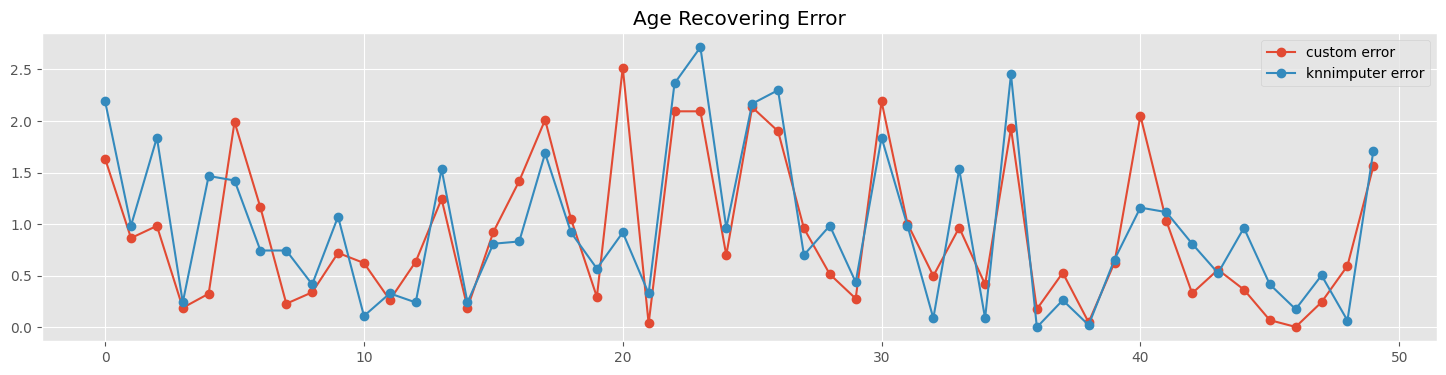

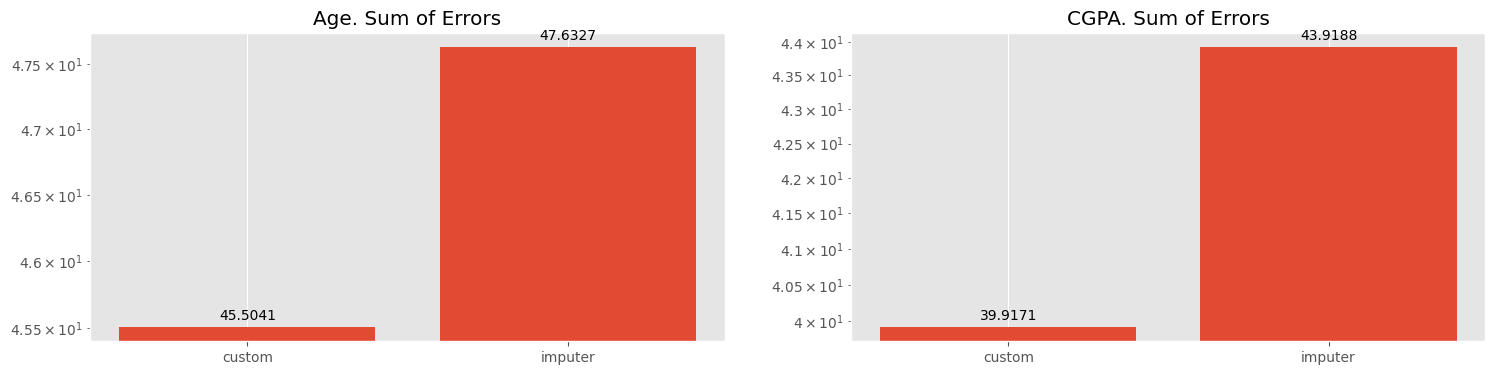

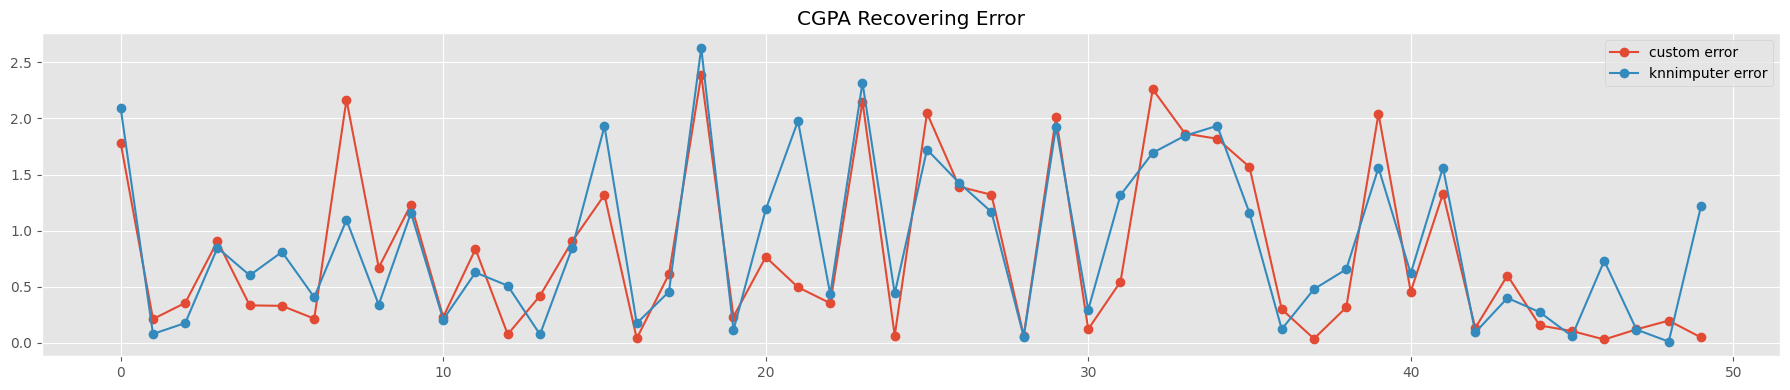

In [92]:
fig, axs = plt.subplots(1, figsize=(18, 4))

axs.plot(comparison['error_custom_age'], marker='o', label='custom error')
axs.plot(comparison['error_imputer_age'], marker='o', label='knnimputer error')
axs.set_title('Age Recovering Error')
axs.legend()

fig, axs = plt.subplots(1, 2, figsize=(18, 4))

bars = axs[0].bar(['custom', 'imputer'], comparison[['error_custom_age', 'error_imputer_age']].sum(), log=True)
axs[0].bar_label(bars, padding=3)
axs[0].set_title('Age. Sum of Errors')

bars = axs[1].bar(['custom', 'imputer'], comparison[['error_custom_cgpa', 'error_imputer_cgpa']].sum(), log=True)
axs[1].bar_label(bars, padding=3)
axs[1].set_title('CGPA. Sum of Errors')

fig, axs = plt.subplots(1, figsize=(18, 4))

axs.plot(comparison['error_custom_cgpa'], marker='o', label='custom error')
axs.plot(comparison['error_imputer_cgpa'], marker='o', label='knnimputer error')
axs.set_title('CGPA Recovering Error')
axs.legend()

plt.tight_layout()

In [49]:
FULL_BASE = df_transform.dropna().drop(['age', 'cgpa'], axis=1).copy()
FULL_BASE = FULL_BASE.drop_duplicates()
FULL_BASE.reset_index(drop=True, inplace=True)

test_idxs = rng.integers(low=0, high=FULL_BASE.shape[0], size=50)

test_data = FULL_BASE.loc[test_idxs].copy()
test_data['nan'] = [[] for _ in range(len(test_data))]
data_for_imputer = FULL_BASE.copy()
FULL_BASE = FULL_BASE.drop(test_idxs)

data_for_imputer.shape, FULL_BASE.shape, test_data.shape

((189, 5), (144, 5), (50, 6))

In [51]:
NAME = test_data.drop('name', axis=1)
NAME['name'] = NAME.apply(recovery, col_for_recovery='name', metric='manhattan', axis=1)

CITY = test_data.drop('city', axis=1)
CITY['city'] = CITY.apply(recovery, col_for_recovery='city', metric='manhattan', axis=1)

GENDER = test_data.drop('gender', axis=1)
GENDER['gender'] = GENDER.apply(recovery, col_for_recovery='gender', metric='manhattan', axis=1)

PROFF = test_data.drop('profession', axis=1)
PROFF['profession'] = PROFF.apply(recovery, col_for_recovery='profession', metric='manhattan', axis=1)